The code below uses a solution to the NS equations that simulate flow in a vortex, spinning around the center of the mesh. Pressure for this example is lowest at the center of the vortex and increases outward due to centrifugal forces.

In [12]:
%load_ext autoreload
%autoreload 2

import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from petsc4py import PETSc
# Add current directory to path just in case
sys.path.append(os.path.abspath('../src'))

from tutorial_module import NavierStokesSolver

# 3. Vortex / Solid Body Rotation
solver = NavierStokesSolver(
    n_cells=16,
    exact_u=lambda t, x, y: -(y - 0.5),          # Circular flow around the center
    exact_v=lambda t, x, y: (x - 0.5),           # Circular flow around the center
    exact_p=lambda t, x, y: 0.5 * ((x-0.5)**2 + (y-0.5)**2) # Pressure bowl (lowest in center)
)

# (Run your plotting code here to see the beautiful parabolic arrows!)
solver.create_mesh()
solver.setup_discretization()

# This runs the TS solver and returns the PETSc Vec containing the solution
solution = solver.solve()
print(f"Solver finished at time: {solver.ts.getTime()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
L2 Error Norm: 0.00e+00
Solver finished at time: 0.05


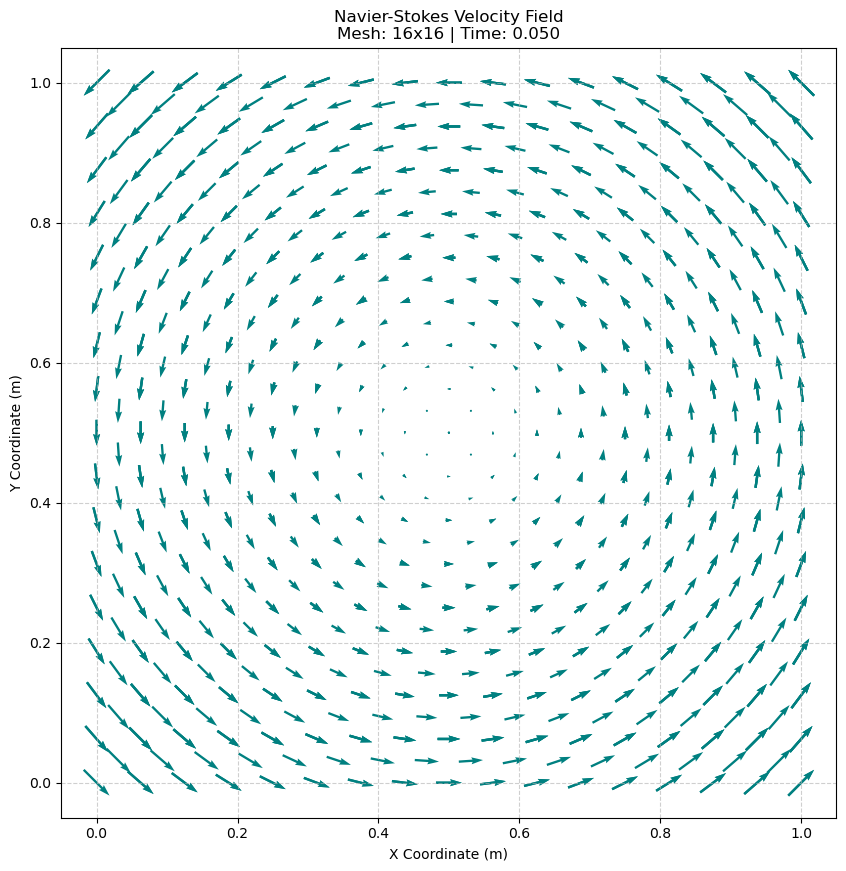

In [13]:
# 1. Access the raw data arrays
u_array = solution.getArray(readonly=True)
sol_section = solver.dm.getGlobalSection()

# 2. Access the coordinate mapping objects
coord_sec = solver.dm.getCoordinateSection()
coords_vec = solver.dm.getCoordinatesLocal()
coords_arr = coords_vec.getArray(readonly=True)

# Storage for plotting
x_vals, y_vals, u_vel, v_vel = [], [], [], []

# 3. Iterate over the entire mesh chart (vertices + edges + faces)
pStart, pEnd = solver.dm.getChart()

for pt in range(pStart, pEnd):
    # Determine if this point carries Velocity in the solution vector
    dof = sol_section.getDof(pt)
    off = sol_section.getOffset(pt)
    
    # If off >= 0, the point exists on this processor rank
    # If dof >= 2, the point carries at least u and v velocity components
    if off >= 0 and dof >= 2:
        # Use our helper function to find the REAL (x,y) location
        # This handles vertices AND the midpoints of edges (Q2 nodes)
        x, y = solver._get_true_coords(pt, coord_sec, coords_arr)
        
        # Append coordinates
        x_vals.append(x)
        y_vals.append(y)
        
        # Extract u and v from the solution vector
        # Taylor-Hood ordering at a point is [u, v, p] or [u, v]
        u_vel.append(u_array[off])
        v_vel.append(u_array[off+1])

# 4. Generate the Plot
plt.figure(figsize=(10, 10))

# Quiver plot configuration:
# pivot='mid' places the center of the arrow on the coordinate
# scale=15 adjusts arrow length; decrease for larger arrows
Q = plt.quiver(x_vals, y_vals, u_vel, v_vel, 
               color='teal', 
               pivot='mid', 
               scale=15, 
               width=0.003)

# Add a grid and set limits to show the full 1.0 x 1.0 domain
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.title(f"Navier-Stokes Velocity Field\nMesh: {solver.n}x{solver.n} | Time: {solver.ts.getTime():.3f}")

plt.savefig("example_vortex.png")
plt.show()

The above plot can be seen to have vector arrows with little magnitude nearing the center of the mesh, and greater magnitude towards the edges. You may notice that the structure of the plot appears somewhat unlike a circular pattern, in that as you view the plot as a whole the arrows seem to create diamond-like shapes. This is due to the locations of the arrows relative to each face of the mesh, in a grid pattern.